## Model v4 + Classifier

### v3 문제점 → v4 수정사항
| # | v3 문제 | v4 수정 | 근거 |
|---|---------|---------|------|
| 1 | **Noise aug 타겟 오류**: 노이즈 신호→노이즈 재구성 학습 → std.mean 0.220으로 붕괴 | **Denoising 방식**: x_noisy→encoder, x_clean→loss target | 노이즈 제거 능력 학습 + posterior 안정화 |
| 2 | **Free Bits KL free_bits=0.5 과도**: 모든 차원 KL≥0.5 강제 → std 붕괴 부작용 | **free_bits=0.1로 낮춤** + detach 방식 명확화 | 과도한 KL 강제 완화 |
| 3 | **warmup 짧음**: 20 epoch → KL이 너무 빨리 켜짐 | **warmup 30으로 늘림** | posterior 안정적으로 형성 후 KL 적용 |

## 1. Google Drive + vtac 설정

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, time
VTAC_ZIP = '/content/drive/MyDrive/vtac.zip'
VTAC_OUT = '/content/vtac_unzipped'

if not os.path.exists(VTAC_OUT) or len(os.listdir(VTAC_OUT)) == 0:
    print('vtac.zip 복사 중...')
    t0 = time.time()
    os.makedirs(VTAC_OUT, exist_ok=True)
    os.system(f'cp "{VTAC_ZIP}" /content/vtac.zip')
    os.system(f'unzip -q /content/vtac.zip -d {VTAC_OUT}')
    print(f'완료! ({time.time()-t0:.0f}초)')
else:
    print('이미 압축 해제됨 — 건너뜀')


Mounted at /content/drive
vtac.zip 복사 중...
완료! (131초)


## 2. Import

In [ ]:
!pip install PyWavelets scikit-learn -q

import os, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pywt
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve

SEED = 42
def set_seed(s=42):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.backends.cudnn.benchmark = True
print('device:', device)


device: cuda


## 3. 경로 설정

In [ ]:
DATA_DIR = '/content/drive/MyDrive/vtac_preprocessed_10s_v2'
TRAIN_PT = f'{DATA_DIR}/train_10s_v2.pt'
VAL_PT   = f'{DATA_DIR}/val_10s_v2.pt'
TEST_PT  = f'{DATA_DIR}/test_10s_v2.pt'

OUT_DIR = '/content/drive/MyDrive/vtac_project/outputs/cvae_v4'
os.makedirs(OUT_DIR, exist_ok=True)

print('DATA_DIR:', DATA_DIR)
print('OUT_DIR:', OUT_DIR)
!ls -lh "{DATA_DIR}" 2>/dev/null || echo '❌ Preprocess_v2.ipynb 먼저 실행하세요'


DATA_DIR: /content/drive/MyDrive/vtac_preprocessed_10s_v2
OUT_DIR: /content/drive/MyDrive/vtac_project/outputs/cvae_v4
❌ Preprocess_v2.ipynb 먼저 실행하세요


## 4. 데이터 로드

In [ ]:
def safe_load(path):
    try:    return torch.load(path, map_location='cpu', weights_only=False)
    except: return torch.load(path, map_location='cpu')

def load_split(path):
    d = safe_load(path)
    X, y, m = d['X'].float(), d['y'].long(), d['m_channel'].float()
    print(path.split('/')[-1], '| X:', tuple(X.shape),
          '| label:', torch.bincount(y, minlength=2).tolist(),
          '| ch avail:', m.sum(0).long().tolist())
    return X, y, m, d

X_train, y_train, m_train, _ = load_split(TRAIN_PT)
X_val,   y_val,   m_val,   _ = load_split(VAL_PT)
X_test,  y_test,  m_test,  _ = load_split(TEST_PT)
CHANNELS = ['ECG1', 'ECG2', 'PPG', 'ABP']


train_10s_v2.pt | X: (3901, 4, 2500) | label: [2754, 1147] | ch avail: [3901, 3901, 3572, 1393]
val_10s_v2.pt | X: (481, 4, 2500) | label: [341, 140] | ch avail: [481, 481, 445, 171]
test_10s_v2.pt | X: (465, 4, 2500) | label: [328, 137] | ch avail: [465, 465, 425, 171]


## 5. Dataset + DataLoader

In [ ]:
C_DIM = 5; LATENT_DIM = 128; BATCH_SIZE = 64; SEQ_LEN = 2500

def make_cond(y, m):
    return torch.cat([y.float().unsqueeze(1), m.float()], dim=1)

c_train = make_cond(y_train, m_train)
c_val   = make_cond(y_val,   m_val)
c_test  = make_cond(y_test,  m_test)

train_ds = TensorDataset(X_train, c_train, m_train)
val_ds   = TensorDataset(X_val,   c_val,   m_val)

cw = 1.0 / torch.bincount(y_train, minlength=2).float()
sampler = WeightedRandomSampler(cw[y_train], len(y_train), replacement=True)

train_loader = DataLoader(train_ds, BATCH_SIZE, sampler=sampler,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print('train:', len(train_ds), '| val:', len(val_ds))


train: 3901 | val: 481


## 6. 모델 아키텍처
### 6-1. ConvBranchEncoder

In [ ]:
class ConvBranchEncoder(nn.Module):
    def __init__(self, in_wave_channels, c_dim, hidden_channels=(32,64,128),
                 out_dim=256, seq_len=2500, norm_groups=8):
        super().__init__()
        self.c_dim   = c_dim
        self.seq_len = seq_len
        ic = in_wave_channels + c_dim

        def gn(ch):
            g = min(norm_groups, ch)
            while ch % g: g -= 1
            return nn.GroupNorm(g, ch)

        self.conv = nn.Sequential(
            nn.Conv1d(ic, hidden_channels[0], 9, stride=2, padding=4), gn(hidden_channels[0]), nn.SiLU(),
            nn.Conv1d(hidden_channels[0], hidden_channels[1], 9, stride=2, padding=4), gn(hidden_channels[1]), nn.SiLU(),
            nn.Conv1d(hidden_channels[1], hidden_channels[2], 7, stride=2, padding=3), gn(hidden_channels[2]), nn.SiLU(),
            nn.Conv1d(hidden_channels[2], hidden_channels[2], 7, stride=1, padding=3), gn(hidden_channels[2]), nn.SiLU(),
        )
        with torch.no_grad():
            d = torch.zeros(1, in_wave_channels + c_dim, seq_len)
            self.flat_dim = self.conv(d).numel()

        self.proj = nn.Sequential(nn.Linear(self.flat_dim, out_dim), nn.LayerNorm(out_dim), nn.SiLU())

    def forward(self, x, c):
        B, _, T = x.shape
        h = torch.cat([x, c.unsqueeze(-1).expand(B, self.c_dim, T)], dim=1)
        return self.proj(self.conv(h).flatten(1))


### 6-2. CrossAttentionFusion

In [ ]:
class CrossAttentionFusion(nn.Module):
    def __init__(self, branch_dim=256, c_dim=5, num_heads=8,
                 fusion_dim=512, dropout=0.2):
        super().__init__()
        self.c_proj = nn.Linear(c_dim, branch_dim)
        self.attn   = nn.MultiheadAttention(branch_dim, num_heads,
                                             dropout=dropout, batch_first=True)
        self.norm1  = nn.LayerNorm(branch_dim)
        self.ffn    = nn.Sequential(
            nn.Linear(branch_dim, branch_dim * 4), nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(branch_dim * 4, branch_dim),
        )
        self.norm2    = nn.LayerNorm(branch_dim)
        self.out_proj = nn.Sequential(
            nn.Linear(3 * branch_dim, fusion_dim), nn.LayerNorm(fusion_dim), nn.SiLU(),
            nn.Linear(fusion_dim, fusion_dim),     nn.LayerNorm(fusion_dim), nn.SiLU(),
        )

    def forward(self, h_ecg, h_ppg, h_abp, c):
        c_emb  = self.c_proj(c)
        tokens = torch.stack([h_ecg + c_emb, h_ppg + c_emb, h_abp + c_emb], dim=1)
        attn_out, _ = self.attn(tokens, tokens, tokens)
        tokens = self.norm1(tokens + attn_out)
        tokens = self.norm2(tokens + self.ffn(tokens))
        return self.out_proj(tokens.flatten(1))


### 6-3. MultiBranchCVAE

In [ ]:
class MultiBranchCVAE(nn.Module):
    def __init__(self, x_channels=4, c_dim=5, latent_dim=128, seq_len=2500,
                 branch_dim=256, fusion_dim=512, num_heads=8, norm_groups=8):
        super().__init__()
        self.x_channels = x_channels
        self.c_dim      = c_dim
        self.latent_dim = latent_dim
        self.seq_len    = seq_len
        self.branch_dim = branch_dim

        self.ecg_encoder = ConvBranchEncoder(2, c_dim, out_dim=branch_dim, seq_len=seq_len, norm_groups=norm_groups)
        self.ppg_encoder = ConvBranchEncoder(1, c_dim, out_dim=branch_dim, seq_len=seq_len, norm_groups=norm_groups)
        self.abp_encoder = ConvBranchEncoder(1, c_dim, out_dim=branch_dim, seq_len=seq_len, norm_groups=norm_groups)

        self.fusion    = CrossAttentionFusion(branch_dim, c_dim, num_heads, fusion_dim)
        self.fc_mu     = nn.Linear(fusion_dim, latent_dim)
        self.fc_logvar = nn.Linear(fusion_dim, latent_dim)

        self.dec_len      = seq_len // 4
        self.dec_channels = 128
        self.fc_dec = nn.Sequential(
            nn.Linear(latent_dim + c_dim, fusion_dim), nn.LayerNorm(fusion_dim), nn.SiLU(),
            nn.Linear(fusion_dim, self.dec_channels * self.dec_len), nn.SiLU(),
        )
        self.decoder = nn.Sequential(
            nn.Conv1d(128, 128, 7, padding=3), nn.SiLU(),
            nn.Upsample(scale_factor=2, mode='linear', align_corners=False),
            nn.Conv1d(128, 64, 7, padding=3), nn.SiLU(),
            nn.Upsample(scale_factor=2, mode='linear', align_corners=False),
            nn.Conv1d(64, 32, 7, padding=3), nn.SiLU(),
            nn.Conv1d(32, x_channels, 9, padding=4),
        )

    def _match_len(self, x, n):
        t = x.shape[-1]
        if t == n: return x
        return x[..., :n] if t > n else F.pad(x, (0, n - t))

    def _gates(self, c):
        if c.size(1) < 5:
            o = torch.ones(c.size(0), 1, device=c.device, dtype=c.dtype)
            return o, o, o
        return torch.clamp(c[:,1:2]+c[:,2:3], 0, 1), c[:,3:4], c[:,4:5]

    def encode(self, x, c):
        g_e, g_p, g_a = self._gates(c)
        h_e = self.ecg_encoder(x[:,0:2,:], c) * g_e
        h_p = self.ppg_encoder(x[:,2:3,:], c) * g_p
        h_a = self.abp_encoder(x[:,3:4,:], c) * g_a
        h   = self.fusion(h_e, h_p, h_a, c)
        mu     = self.fc_mu(h)
        logvar = torch.clamp(self.fc_logvar(h), -10, 10)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        return mu + torch.randn_like(mu) * torch.exp(0.5 * torch.clamp(logvar, -10, 10))

    def decode(self, z, c, m_channel=None):
        h = self.fc_dec(torch.cat([z, c], 1))
        h = h.view(z.size(0), self.dec_channels, self.dec_len)
        x_hat = self._match_len(self.decoder(h), self.seq_len)
        if m_channel is not None:
            x_hat = x_hat * m_channel.unsqueeze(-1)
        return x_hat

    def forward(self, x_enc, c, m_channel=None):
        mu, logvar = self.encode(x_enc, c)
        return self.decode(self.reparameterize(mu, logvar), c, m_channel), mu, logvar

    @torch.no_grad()
    def reconstruct(self, x, c, m_channel=None, use_mean=True):
        self.eval()
        mu, logvar = self.encode(x, c)
        z = mu if use_mean else self.reparameterize(mu, logvar)
        return self.decode(z, c, m_channel)

    @torch.no_grad()
    def sample_prior(self, c, n=None, z_scale=0.7, m_channel=None):
        self.eval()
        if n is None: n = c.size(0)
        if c.size(0) == 1 and n > 1: c = c.expand(n, -1)
        z = torch.randn(n, self.latent_dim, device=c.device, dtype=c.dtype) * z_scale
        return self.decode(z, c, m_channel)


## 7. 손실함수

In [ ]:
def masked_recon_loss(x, x_hat, m, eps=1e-8):
    mask = m.to(x.dtype).unsqueeze(-1)
    return ((x - x_hat)**2 * mask).sum() / (mask.sum() * x.shape[-1] + eps)

def masked_derivative_loss(x, x_hat, m, eps=1e-8):
    mask = m.to(x.dtype).unsqueeze(-1)
    dx, dxh = x[:,:,1:]-x[:,:,:-1], x_hat[:,:,1:]-x_hat[:,:,:-1]
    return ((dx - dxh)**2 * mask).sum() / (mask.sum() * dx.shape[-1] + eps)

def masked_std_loss(x, x_hat, m, eps=1e-8):
    mask = m.to(x.dtype)
    return ((x.std(-1) - x_hat.std(-1))**2 * mask).sum() / (mask.sum() + eps)

def temporal_focus_recon_loss(
    x,
    x_hat,
    m,
    focus_start=750,
    focus_end=1500,
    focus_weight=2.0,
    ecg_focus_weight=3.0,
    eps=1e-8,
):
    """
    Grad-CAM guided temporal reconstruction loss.

    Window: [-10s, 0s], fs=250Hz
    -7s  -> index 750
    -4s  -> index 1500

    General channels: focus region weight = 2.0
    ECG1/ECG2: focus region weight = 3.0
    """
    mask = m.to(x.dtype).unsqueeze(-1)

    weight = torch.ones_like(x)
    weight[:, :, focus_start:focus_end] = focus_weight
    weight[:, 0:2, focus_start:focus_end] = ecg_focus_weight

    diff = (x - x_hat).abs() * weight
    diff = diff * mask

    return diff.sum() / (mask.sum() * x.shape[-1] + eps)

def ecg_slope_focus_loss(
    x,
    x_hat,
    m,
    focus_start=750,
    focus_end=1500,
    slope_weight=3.0,
    eps=1e-8,
):
    """
    ECG-specific slope preservation loss.

    Emphasizes high-slope ECG regions in the Grad-CAM important interval.
    This targets QRS-like sharp transitions that were smoothed in synthetic ECG.
    """
    # ECG1, ECG2 only
    x_ecg = x[:, 0:2, :]
    h_ecg = x_hat[:, 0:2, :]
    m_ecg = m[:, 0:2].to(x.dtype)

    dx = x_ecg[:, :, 1:] - x_ecg[:, :, :-1]
    dh = h_ecg[:, :, 1:] - h_ecg[:, :, :-1]

    # derivative index length is T-1, so use same approximate interval
    fs = max(0, focus_start)
    fe = min(dx.shape[-1], focus_end)

    base_weight = torch.ones_like(dx)

    # Put stronger emphasis on the CAM-important interval.
    base_weight[:, :, fs:fe] = 2.0

    # Within that interval, high-slope regions get additional weight.
    slope_amp = 1.0 + slope_weight * dx.abs()
    weight = base_weight * slope_amp

    loss = (dx - dh).abs() * weight
    loss = loss * m_ecg.unsqueeze(-1)

    return loss.sum() / (m_ecg.unsqueeze(-1).sum() * dx.shape[-1] + eps)

def kl_beta_anneal(epoch, beta_max=1e-3, warmup=30):
    return beta_max * min(1.0, epoch / max(warmup, 1))

def kl_free_bits_v4(mu, logvar, free_bits=0.1):
    logvar = torch.clamp(logvar, -10.0, 10.0)
    kl_per_dim = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
    threshold  = torch.full_like(kl_per_dim, free_bits).detach()
    return torch.max(kl_per_dim, threshold).mean()

def _haar_dwt1d(x):
    if x.shape[-1] % 2: x = F.pad(x, (0, 1))
    return (x[:,:,0::2]+x[:,:,1::2])*0.5, (x[:,:,0::2]-x[:,:,1::2])*0.5

def masked_wavelet_loss(x, x_hat, m, n_levels=4, eps=1e-8):
    mask = m.to(x.dtype).unsqueeze(-1)
    total, n = torch.tensor(0., device=x.device, dtype=x.dtype), 0
    cx, cxh = x, x_hat
    for _ in range(n_levels):
        lo, hi   = _haar_dwt1d(cx)
        loh, hih = _haar_dwt1d(cxh)
        total += ((hi-hih).abs()*mask).sum()/(mask.sum()*hi.shape[-1]+eps)
        n += 1; cx, cxh = lo, loh
    total += ((cx-cxh).abs()*mask).sum()/(mask.sum()*cx.shape[-1]+eps)
    return total / (n+1)

def _max_xcorr(ecg, pulse, tau_max=100, step=5, eps=1e-8):
    en = (ecg   - ecg.mean(-1, keepdim=True))   / (ecg.std(-1, keepdim=True)   + eps)
    pn = (pulse - pulse.mean(-1, keepdim=True)) / (pulse.std(-1, keepdim=True) + eps)
    xcorrs = []
    for tau in range(0, tau_max+1, step):
        sp = pn if tau==0 else torch.cat([pn[:,tau:], torch.zeros_like(pn[:,:tau])], -1)
        xcorrs.append((en*sp).mean(-1))
    return torch.stack(xcorrs, -1).max(-1).values

def ecg_pulse_coupling_loss(x, x_hat, m, tau_max=100, step=5, eps=1e-8):
    m_e, m_p, m_a = m[:,0], m[:,2], m[:,3]
    er, eg = x[:,0,:], x_hat[:,0,:]
    total, cnt = torch.tensor(0., device=x.device, dtype=x.dtype), 0
    for ch_idx, mv in [(2, m_p), (3, m_a)]:
        valid = (m_e>0) & (mv>0)
        if valid.sum() > 0:
            cr = _max_xcorr(er[valid], x[valid,ch_idx,:],     tau_max, step, eps)
            cg = _max_xcorr(eg[valid], x_hat[valid,ch_idx,:], tau_max, step, eps)
            total += (cr-cg).abs().mean(); cnt += 1
    return total / max(cnt, 1)

def cvae_loss_v4(
    x_clean,
    x_hat,
    mu,
    logvar,
    m,
    beta=1e-3,
    gamma_deriv=0.5,
    gamma_std=0.1,
    lambda_wav=0.1,
    lambda_phys=0.05,
    gamma_focus=0.5,
    gamma_ecg_slope=0.2,
    free_bits=0.1,
):
    recon = masked_recon_loss(x_clean, x_hat, m)
    deriv = masked_derivative_loss(x_clean, x_hat, m)
    std   = masked_std_loss(x_clean, x_hat, m)
    wav   = masked_wavelet_loss(x_clean, x_hat, m)
    phys  = ecg_pulse_coupling_loss(x_clean, x_hat, m)

    # Grad-CAM guided losses
    focus = temporal_focus_recon_loss(
        x=x_clean,
        x_hat=x_hat,
        m=m,
        focus_start=750,
        focus_end=1500,
        focus_weight=2.0,
        ecg_focus_weight=3.0,
    )

    ecg_slope = ecg_slope_focus_loss(
        x=x_clean,
        x_hat=x_hat,
        m=m,
        focus_start=750,
        focus_end=1500,
        slope_weight=3.0,
    )

    kl = kl_free_bits_v4(mu, logvar, free_bits)

    loss = (
        recon
        + gamma_deriv * deriv
        + gamma_std * std
        + lambda_wav * wav
        + lambda_phys * phys
        + gamma_focus * focus
        + gamma_ecg_slope * ecg_slope
        + beta * kl
    )

    return loss, {
        "loss": loss.detach(),
        "recon": recon.detach(),
        "deriv": deriv.detach(),
        "std": std.detach(),
        "wav": wav.detach(),
        "phys": phys.detach(),
        "focus": focus.detach(),
        "ecg_slope": ecg_slope.detach(),
        "kl": kl.detach(),
    }

## 8. CVAE 학습 함수 (Denoising Augmentation)

In [ ]:
def augment_signals(x, m_channel, noise_std=0.05):
    noise = torch.randn_like(x) * noise_std
    return x + noise * m_channel.unsqueeze(-1)


def run_epoch_v4(model, loader, optimizer=None, device='cuda',
                 epoch=1, beta_max=1e-3, warmup=30,
                 gamma_deriv=0.5, gamma_std=0.1,
                 lambda_wav=0.1, lambda_phys=0.05,
                 gamma_focus=0.5, gamma_ecg_slope=0.2,
                 grad_clip=1.0, free_bits=0.1, noise_std=0.05):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    beta = kl_beta_anneal(epoch, beta_max, warmup)
    totals = {k: 0. for k in ['loss','recon','deriv','std','wav','phys','focus','ecg_slope','kl']}
    nb = 0
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for batch in loader:
            x_clean, c, m = [t.to(device).float() for t in batch]
            x_enc = augment_signals(x_clean, m, noise_std) if (is_train and noise_std>0) else x_clean
            if is_train: optimizer.zero_grad(set_to_none=True)
            x_hat, mu, logvar = model(x_enc, c, m_channel=m)
            loss, logs = cvae_loss_v4(
                                        x_clean,
                                        x_hat,
                                        mu,
                                        logvar,
                                        m,
                                        beta=beta,
                                        gamma_deriv=gamma_deriv,
                                        gamma_std=gamma_std,
                                        lambda_wav=lambda_wav,
                                        lambda_phys=lambda_phys,
                                        gamma_focus=gamma_focus,
                                        gamma_ecg_slope=gamma_ecg_slope,
                                        free_bits=free_bits,
                                    )
            if is_train:
                loss.backward()
                if grad_clip: torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                optimizer.step()
            for k in totals: totals[k] += logs[k].item()
            nb += 1
    r = {k: totals[k]/nb for k in totals}
    r['beta'] = beta
    return r


def train_v4(model, train_loader, val_loader=None, device='cuda',
             epochs=60, lr=1e-3, weight_decay=1e-4,
             beta_max=1e-3, warmup=30, gamma_deriv=0.5, gamma_std=0.1,
             lambda_wav=0.1, lambda_phys=0.05,
             gamma_focus=0.5, gamma_ecg_slope=0.2,
             grad_clip=1.0, free_bits=0.1, noise_std=0.05, save_path=None):
    model = model.to(device)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr*0.01)
    history = {'train': [], 'val': []}
    best_val, best_ep = float('inf'), -1
    for ep in range(1, epochs+1):
        tr = run_epoch_v4(
            model, train_loader, opt, device, ep,
            beta_max, warmup, gamma_deriv, gamma_std,
            lambda_wav, lambda_phys,
            gamma_focus, gamma_ecg_slope,
            grad_clip, free_bits, noise_std
            )
        sched.step()
        history['train'].append(tr)
        vl = None
        if val_loader:
            vl = run_epoch_v4(
                model, val_loader, None, device, ep,
                beta_max, warmup, gamma_deriv, gamma_std,
                lambda_wav, lambda_phys,
                gamma_focus, gamma_ecg_slope,
                grad_clip, free_bits, noise_std=0.0
                )
            history['val'].append(vl)
            if vl['loss'] < best_val:
                best_val, best_ep = vl['loss'], ep
                if save_path:
                    torch.save({'model_state_dict': model.state_dict(),
                                'history': history, 'epoch': ep}, save_path)
        if ep == 1 or ep % 5 == 0:
            msg = (
                f'Ep {ep:03d} | tr loss={tr["loss"]:.4f} recon={tr["recon"]:.4f} '
                f'focus={tr["focus"]:.4f} ecg_slope={tr["ecg_slope"]:.4f} '
                f'wav={tr["wav"]:.4f} phys={tr["phys"]:.4f} kl={tr["kl"]:.2f}'
                )
            if vl:
                msg += (
                    f' | val loss={vl["loss"]:.4f} recon={vl["recon"]:.4f} '
                    f'focus={vl["focus"]:.4f} ecg_slope={vl["ecg_slope"]:.4f}'
                    )
            print(msg)
    print(f'Best epoch: {best_ep} | best val loss: {best_val:.6f}')

    # Reload best checkpoint before returning
    if save_path is not None and os.path.exists(save_path):
        ckpt = torch.load(save_path, map_location=device, weights_only=False)
        model.load_state_dict(ckpt["model_state_dict"])
        model.eval()
        print(f'Reloaded best checkpoint: epoch={ckpt["epoch"]}, val_loss={best_val:.6f}')

    return model, history


## 9. 학습 실행

In [ ]:
model = MultiBranchCVAE(
    x_channels=4, c_dim=C_DIM, latent_dim=LATENT_DIM,
    seq_len=SEQ_LEN, branch_dim=256, fusion_dim=512, num_heads=8,
).to(device)

print(f'파라미터 수: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

SAVE_PATH = f'{OUT_DIR}/cvae_v4_focus_ecg_best.pt'

model, history = train_v4(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=60,
    lr=1e-3,
    weight_decay=1e-4,
    beta_max=1e-3,
    warmup=30,
    gamma_deriv=0.5,
    gamma_std=0.1,
    lambda_wav=0.1,
    lambda_phys=0.05,
    gamma_focus=0.5,
    gamma_ecg_slope=0.2,
    grad_clip=1.0,
    free_bits=0.1,
    noise_std=0.05,
    save_path=SAVE_PATH,
)
print('저장 완료:', SAVE_PATH)


파라미터 수: 74,229,924
Ep 001 | tr loss=1.1136 recon=0.9913 wav=0.2181 phys=0.1402 kl=1.17 | val loss=1.1144 recon=0.9938
Ep 005 | tr loss=1.0858 recon=0.9774 wav=0.2164 phys=0.1103 kl=1.27 | val loss=1.0947 recon=0.9855
Ep 010 | tr loss=1.0667 recon=0.9636 wav=0.2151 phys=0.1084 kl=1.13 | val loss=1.0823 recon=0.9778
Ep 015 | tr loss=1.0198 recon=0.9282 wav=0.2128 phys=0.1053 kl=1.70 | val loss=1.0622 recon=0.9673
Ep 020 | tr loss=0.9840 recon=0.8995 wav=0.2114 phys=0.1026 kl=1.71 | val loss=1.0674 recon=0.9748
Ep 025 | tr loss=0.9281 recon=0.8515 wav=0.2090 phys=0.0956 kl=1.85 | val loss=1.0967 recon=1.0108
Ep 030 | tr loss=0.8362 recon=0.7692 wav=0.2020 phys=0.0843 kl=2.18 | val loss=1.1353 recon=1.0542
Ep 035 | tr loss=0.7249 recon=0.6664 wav=0.1912 phys=0.0785 kl=2.46 | val loss=1.1959 recon=1.1209
Ep 040 | tr loss=0.6324 recon=0.5804 wav=0.1804 phys=0.0680 kl=2.69 | val loss=1.2264 recon=1.1531
Ep 045 | tr loss=0.5682 recon=0.5207 wav=0.1729 phys=0.0577 kl=2.86 | val loss=1.2717 reco

## 10. 학습 곡선

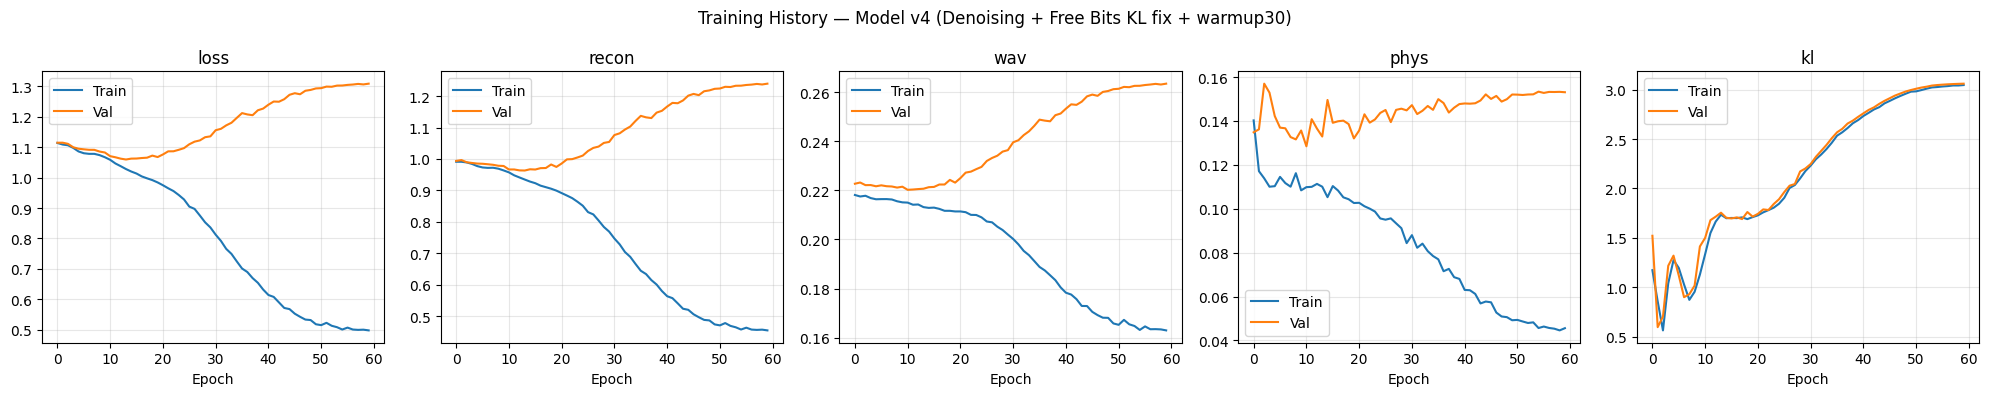

In [ ]:
def plot_history(history, title='v4'):
    keys = ['loss','recon','focus','ecg_slope','wav','phys','kl']
    fig, axes = plt.subplots(1, len(keys), figsize=(20, 4))
    for ax, k in zip(axes, keys):
        ax.plot([h[k] for h in history['train']], label='Train')
        if history['val']:
            ax.plot([h.get(k,0) for h in history['val']], label='Val')
        ax.set_title(k); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True, alpha=0.3)
    plt.suptitle(f'Training History — Model {title}')
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history, 'v4 + Temporal Focus + ECG Slope Loss')

## 11. 재구성 시각화

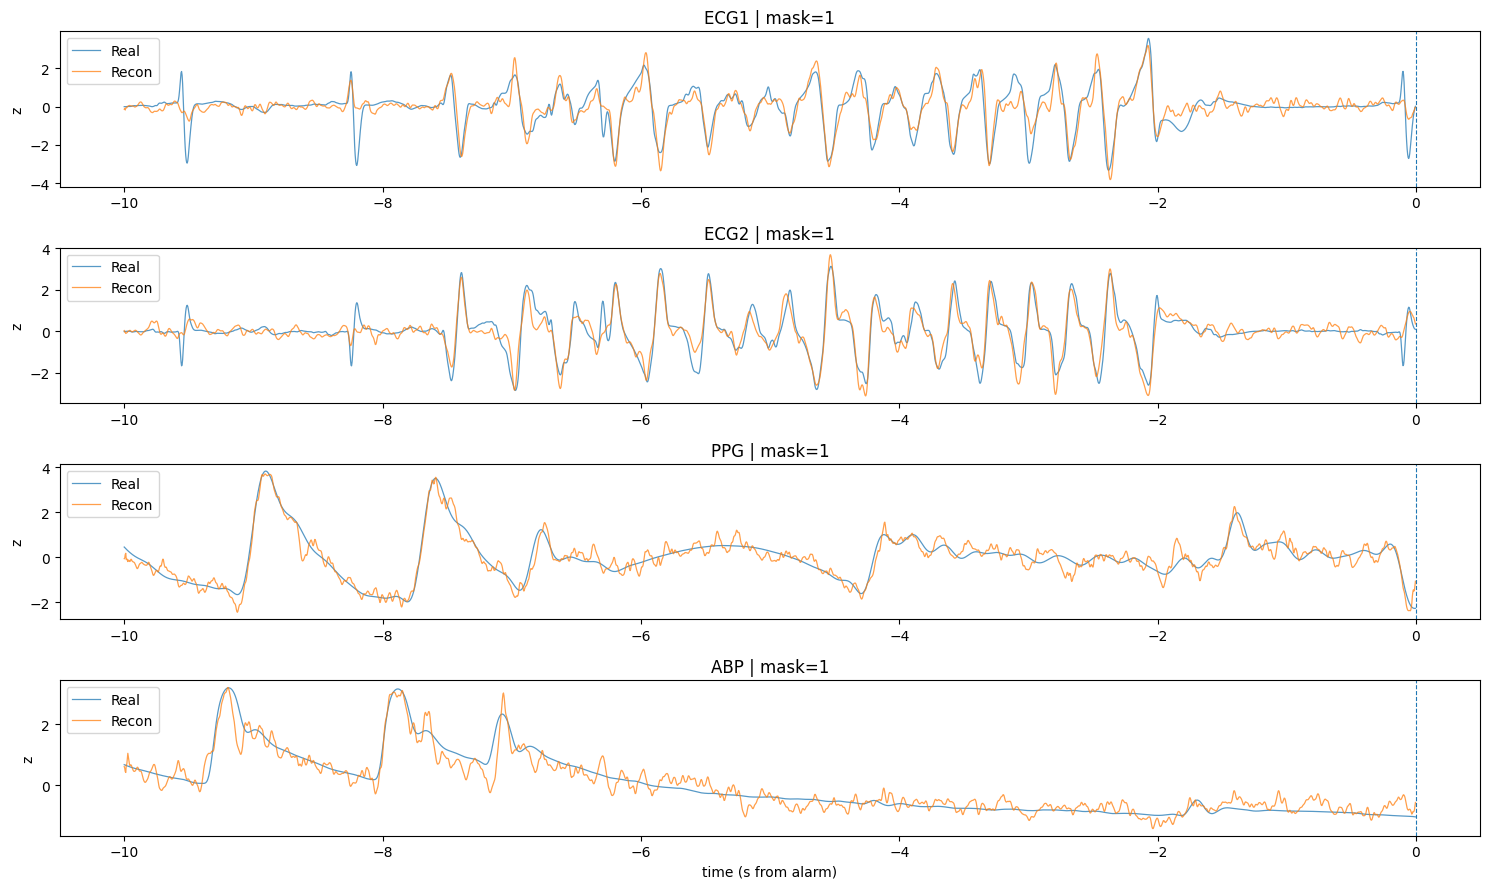

3841

In [ ]:
@torch.no_grad()
def plot_recon(model, X, y, m, idx=None, true_only=True, fs=250):
    model.eval()
    if idx is None:
        cands = np.where(y.numpy()==1)[0] if true_only else np.arange(len(y))
        idx = int(np.random.choice(cands))
    xb = X[idx:idx+1].to(device)
    yb = y[idx:idx+1].to(device)
    mb = m[idx:idx+1].to(device)
    cb = torch.cat([yb.float().unsqueeze(1), mb.float()], 1)
    xh = model.reconstruct(xb, cb, mb, use_mean=True)
    xn, xhn, mn = xb[0].cpu().numpy(), xh[0].cpu().numpy(), mb[0].cpu().numpy().astype(int)
    t = np.arange(xn.shape[1]) / fs - 10
    fig, axes = plt.subplots(4, 1, figsize=(15, 9))
    for i, (ax, ch) in enumerate(zip(axes, ['ECG1','ECG2','PPG','ABP'])):
        if mn[i]:
            ax.plot(t, xn[i],  lw=0.9, alpha=0.75, label='Real')
            ax.plot(t, xhn[i], lw=0.9, alpha=0.75, label='Recon')
        ax.axvline(0, ls='--', lw=0.8)
        ax.set_title(f'{ch} | mask={mn[i]}'); ax.set_ylabel('z'); ax.legend()
    axes[-1].set_xlabel('time (s from alarm)')
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/reconstruction.png', dpi=150, bbox_inches='tight')
    plt.show(); return idx

plot_recon(model, X_train, y_train, m_train)


## 12. True Alarm 샘플 생성

In [ ]:
@torch.no_grad()
def generate(model, true_masks, n, z_scale=0.7, bs=128, device='cuda'):
    model.eval()
    if isinstance(true_masks, np.ndarray):
        true_masks = torch.tensor(true_masks, dtype=torch.float32)
    rng = np.random.default_rng(SEED)
    idx = rng.choice(len(true_masks), size=n, replace=True)
    masks = true_masks[idx].float()
    cond  = torch.cat([torch.ones(n, 1), masks], 1)
    outs  = []
    for s in range(0, n, bs):
        cb = cond[s:s+bs].to(device)
        mb = masks[s:s+bs].to(device)
        xb = model.sample_prior(cb, n=cb.size(0), z_scale=z_scale, m_channel=mb)
        outs.append((xb * mb.unsqueeze(-1)).cpu())
    return torch.cat(outs), masks


n_false = int((y_train==0).sum())
n_true  = int((y_train==1).sum())
n_gen   = n_false - n_true

print(f'False: {n_false}, True: {n_true}, 생성: {n_gen}')

X_gen, m_gen = generate(model, m_train[y_train==1], n_gen, device=device)
y_gen = torch.ones(len(X_gen), dtype=torch.long)

print(f'Generated: {X_gen.shape}')
print(f'CVAE sample std: {X_gen.std().item():.4f}  (v3: 0.2427, 목표: ~0.7~1.0)')
print(f'ABP 있는 샘플: {int((m_gen[:,3]==1).sum())} / {len(m_gen)} ({int((m_gen[:,3]==1).sum())/len(m_gen)*100:.1f}%)')

SYN_PATH = f'{OUT_DIR}/generated_true_v4_focus_ecg.pt'

torch.save({
    'X_syn': X_gen,
    'y_syn': y_gen,
    'm_syn': m_gen,
    'method': 'cvae_v4_temporal_focus_ecg_slope',
    'channels': CHANNELS,
    'loss_config': {
        'beta_max': 1e-3,
        'warmup': 30,
        'gamma_deriv': 0.5,
        'gamma_std': 0.1,
        'lambda_wav': 0.1,
        'lambda_phys': 0.05,
        'gamma_focus': 0.5,
        'gamma_ecg_slope': 0.2,
        'focus_region': [750, 1500],
    }
}, SYN_PATH)
print('저장 완료:', SYN_PATH)


False: 2754, True: 1147, 생성: 1607
Generated: torch.Size([1607, 4, 2500])
CVAE sample std: 1.7129  (v3: 0.2427, 목표: ~0.7~1.0)
ABP 있는 샘플: 605 / 1607 (37.6%)
저장 완료


## 13. 생성 신호 시각화

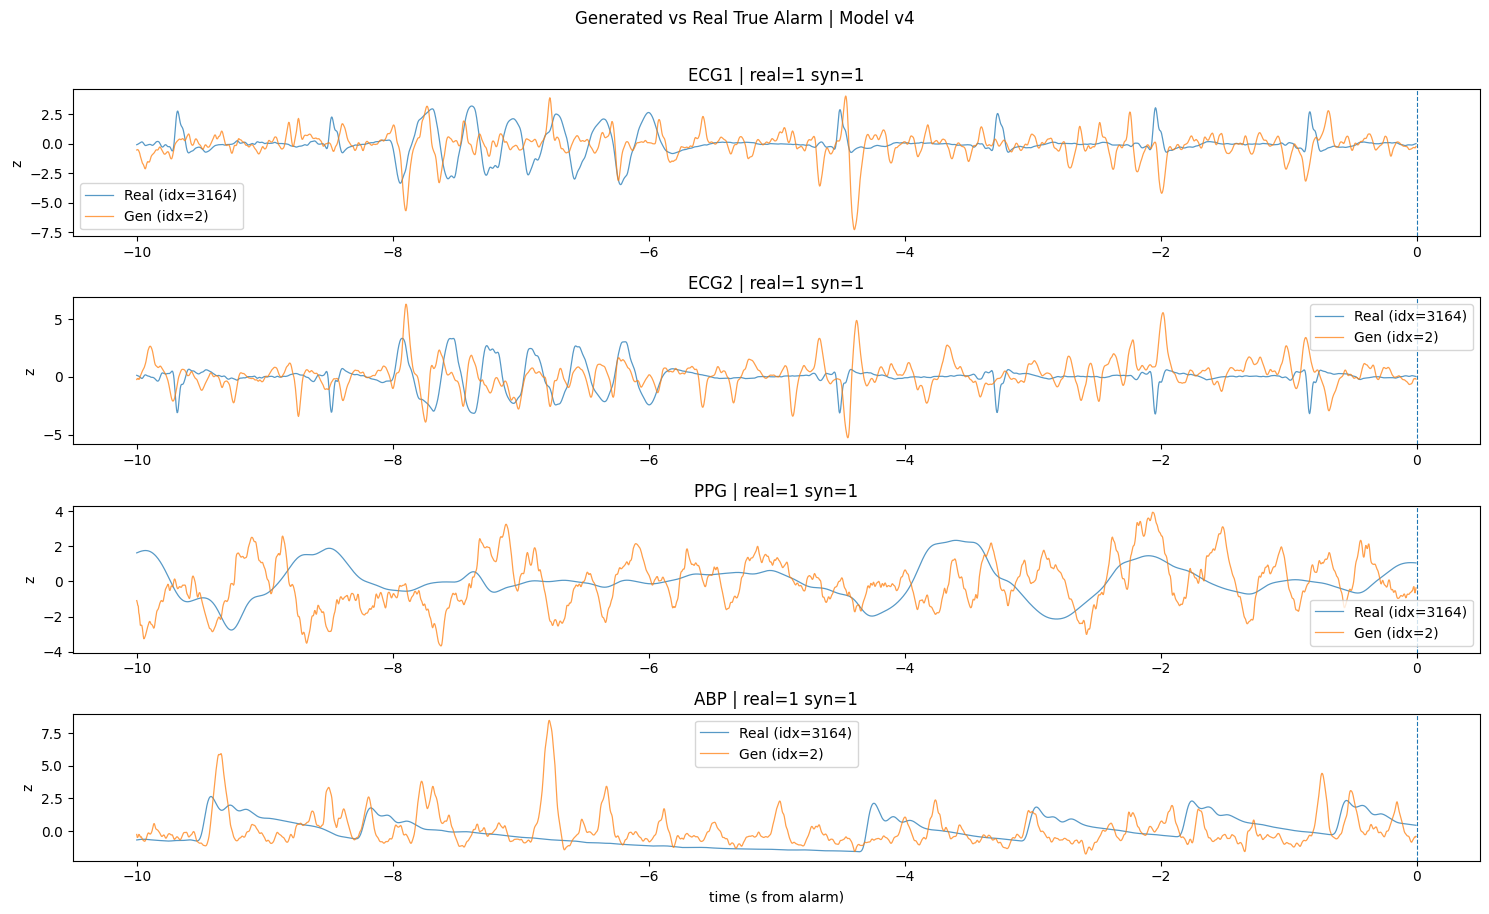

In [ ]:
def _to_np(x): return x.detach().cpu().numpy() if isinstance(x, torch.Tensor) else np.asarray(x)

def plot_gen_vs_real(X_syn, m_syn, X_real, y_real, m_real, syn_idx=None, fs=250):
    if syn_idx is None:
        abp_idx = [i for i,m in enumerate(m_syn) if m[3].item()==1]
        syn_idx = abp_idx[0] if abp_idx else 0
    xs, ms = _to_np(X_syn[syn_idx]), _to_np(m_syn[syn_idx]).astype(int)
    y_np, m_np = _to_np(y_real), _to_np(m_real).astype(int)
    ti = np.where(y_np==1)[0]
    matched = [i for i in ti if np.array_equal(m_np[i], ms)]
    ri = int(np.random.choice(matched if matched else ti))
    xr, mr = _to_np(X_real[ri]), _to_np(m_real[ri]).astype(int)
    t = np.arange(xs.shape[1]) / fs - 10
    fig, axes = plt.subplots(4, 1, figsize=(15, 9))
    for i, (ax, ch) in enumerate(zip(axes, ['ECG1','ECG2','PPG','ABP'])):
        if mr[i]: ax.plot(t, xr[i], lw=0.9, alpha=0.75, label=f'Real (idx={ri})')
        if ms[i]: ax.plot(t, xs[i], lw=0.9, alpha=0.75, label=f'Gen (idx={syn_idx})')
        ax.axvline(0, ls='--', lw=0.8)
        ax.set_title(f'{ch} | real={mr[i]} syn={ms[i]}')
        ax.set_ylabel('z'); ax.legend()
    axes[-1].set_xlabel('time (s from alarm)')
    plt.suptitle('Generated vs Real True Alarm | Model v4', y=1.01)
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/gen_vs_real.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_gen_vs_real(X_gen, m_gen, X_train, y_train, m_train)


## 14. Latent Space 진단

In [ ]:
@torch.no_grad()
def latent_diag(model, X, y, m, n=512, device='cuda'):
    model.eval()
    idx = torch.where(y==1)[0][torch.randperm(int((y==1).sum()))[:n]]
    xb  = X[idx].to(device).float()
    cb  = torch.cat([y[idx].float().unsqueeze(1).to(device),
                     m[idx].float().to(device)], 1)
    mu, logvar = model.encode(xb, cb)
    std = torch.exp(0.5 * logvar)
    print('=== Latent Space 진단 (True Alarm 512개) ===')
    print(f'mu   mean: {mu.mean().item():.4f}  std: {mu.std().item():.4f}')
    print(f'std  mean: {std.mean().item():.4f}  std: {std.std().item():.4f}')
    print(f'logvar mean: {logvar.mean().item():.4f}')
    print()
    print('=== 버전별 비교 ===')
    print('          mu.mean   mu.std   std.mean   logvar.mean   비고')
    print('v1:       -0.0007    0.959     0.184      -3.43        posterior collapse')
    print('v2:       -0.0027    0.508     0.839      -0.596       mu std 붕괴')
    print('v3:       -0.0039    0.637     0.220      -3.119       Free Bits 역효과 + noise aug 오류')
    print(f'v4:       {mu.mean().item():+.4f}   {mu.std().item():.3f}     {std.mean().item():.3f}      {logvar.mean().item():.3f}        <- 현재')
    print()
    print('이상적:   ~0        ~1.0      ~1.0        ~0')
    std_mean = std.mean().item()
    if std_mean < 0.3:
        print('posterior collapse 여전히 있음 (std.mean < 0.3)')
        print('   -> beta_max 낮추거나 free_bits 더 줄이기 검토')
    elif std_mean > 0.6 and mu.std().item() > 0.7:
        print('두 지표 모두 개선됨!')
    else:
        print('부분 개선 — 추가 튜닝 필요')

latent_diag(model, X_train, y_train, m_train, device=device)


=== Latent Space 진단 (True Alarm 512개) ===
mu   mean: -0.0291  std: 0.7819
std  mean: 0.0417  std: 0.0149
logvar mean: -6.4937

=== 버전별 비교 ===
          mu.mean   mu.std   std.mean   logvar.mean   비고
v1:       -0.0007    0.959     0.184      -3.43        posterior collapse
v2:       -0.0027    0.508     0.839      -0.596       mu std 붕괴
v3:       -0.0039    0.637     0.220      -3.119       Free Bits 역효과 + noise aug 오류
v4:       -0.0291   0.782     0.042      -6.494        <- 현재

이상적:   ~0        ~1.0      ~1.0        ~0
posterior collapse 여전히 있음 (std.mean < 0.3)
   -> beta_max 낮추거나 free_bits 더 줄이기 검토


---
## 15. Classifier 정의
### 15-1. 1D-CNN Classifier
채널별 missing mask 처리, 5층 Conv → AdaptiveAvgPool → FC head


In [ ]:
class CNN1DClassifier(nn.Module):
    """
    4채널 멀티모달 신호 분류기.
    missing channel mask를 받아 결측 채널을 0으로 처리한 뒤 분류.
    """
    def __init__(self, in_channels=4, dropout=0.3):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels,  32, 9, stride=2, padding=4), nn.BatchNorm1d(32),  nn.ReLU(),
            nn.Conv1d(32,  64, 9, stride=2, padding=4), nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Conv1d(64, 128, 7, stride=2, padding=3), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Conv1d(128,256, 7, stride=2, padding=3), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Conv1d(256,256, 5, stride=2, padding=2), nn.BatchNorm1d(256), nn.ReLU(),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 2),
        )

    def forward(self, x, m_channel=None):
        if m_channel is not None:
            x = x * m_channel.unsqueeze(-1)
        h = self.pool(self.conv(x)).squeeze(-1)
        return self.head(h)

_test = CNN1DClassifier()
print('CNN1D 출력 shape:', _test(torch.randn(4,4,2500), torch.ones(4,4)).shape)
del _test


CNN1D 출력 shape: torch.Size([4, 2])


### 15-2. FCN Classifier (VTaC NeurIPS 2023 공식 베이스라인)
**구조 (Appendix D)**: Conv×3 + BatchNorm (사이사이) → AdaptiveMaxPool → Dense

VTaC 논문 Table 4에서 Challenge Score 80.08, AUC 0.949로 supervised 중 최고 성능.


In [ ]:
class FCNClassifier(nn.Module):
    """
    VTaC NeurIPS 2023 Appendix D 기반 FCN.
    3 Conv layers + BN + AdaptiveMaxPool + Dense
    논문: 'FCN used 3 convolution layers followed by an adaptive pooling layer.
           Between each convolution, batch normalization was used.
           Lastly, adaptive max pooling followed by a dense layer.'
    """
    def __init__(self, in_channels=4, base_ch=128, dropout=0.2):
        super().__init__()
        self.conv = nn.Sequential(
            # Conv 1
            nn.Conv1d(in_channels, base_ch,    kernel_size=8, stride=1, padding=4),
            nn.BatchNorm1d(base_ch), nn.ReLU(),
            # Conv 2
            nn.Conv1d(base_ch,     base_ch*2,  kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(base_ch*2), nn.ReLU(),
            # Conv 3
            nn.Conv1d(base_ch*2,   base_ch*2,  kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(base_ch*2), nn.ReLU(),
        )
        self.pool = nn.AdaptiveMaxPool1d(1)   # VTaC 논문: adaptive max pooling
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(base_ch*2, 2),          # dense layer → 2-class
        )

    def forward(self, x, m_channel=None):
        if m_channel is not None:
            x = x * m_channel.unsqueeze(-1)
        h = self.pool(self.conv(x)).squeeze(-1)
        return self.head(h)

_test = FCNClassifier()
print('FCN 출력 shape:', _test(torch.randn(4,4,2500), torch.ones(4,4)).shape)
# 파라미터 수 비교
cnn_params = sum(p.numel() for p in CNN1DClassifier().parameters())
fcn_params = sum(p.numel() for p in FCNClassifier().parameters())
print(f'파라미터 수 — CNN1D: {cnn_params:,} | FCN: {fcn_params:,}')
del _test


FCN 출력 shape: torch.Size([4, 2])
파라미터 수 — CNN1D: 669,346 | FCN: 366,978


## 16. Classifier 학습 함수 + AUPRC / AUROC 평가

In [ ]:
def clf_epoch(model, loader, optimizer=None, device='cuda'):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, all_prob, all_true = 0., [], []
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for batch in loader:
            x, y, m = [t.to(device) for t in batch]
            x, m = x.float(), m.float()
            logit = model(x, m)
            loss  = F.cross_entropy(logit, y)
            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
            total_loss += loss.item()
            all_prob.append(F.softmax(logit, 1)[:, 1].detach().cpu())
            all_true.append(y.cpu())
    probs = torch.cat(all_prob).numpy()
    trues = torch.cat(all_true).numpy()
    auprc = average_precision_score(trues, probs)
    auroc = roc_auc_score(trues, probs)
    return total_loss/len(loader), auprc, auroc


def train_classifier(clf, train_loader, val_loader,
                     device='cuda', epochs=40, lr=3e-4,
                     weight_decay=1e-4, patience=8, label='clf'):
    clf = clf.to(device)
    opt   = torch.optim.AdamW(clf.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr*0.01)
    best_auprc, best_state, wait = 0., None, 0
    history = {'tr_loss':[], 'tr_auprc':[], 'val_loss':[], 'val_auprc':[], 'val_auroc':[]}
    for ep in range(1, epochs+1):
        tr_loss, tr_auprc, _           = clf_epoch(clf, train_loader, opt, device)
        val_loss, val_auprc, val_auroc = clf_epoch(clf, val_loader,   None, device)
        sched.step()
        history['tr_loss'].append(tr_loss);    history['tr_auprc'].append(tr_auprc)
        history['val_loss'].append(val_loss);  history['val_auprc'].append(val_auprc)
        history['val_auroc'].append(val_auroc)
        if val_auprc > best_auprc:
            best_auprc = val_auprc
            best_state = {k: v.cpu().clone() for k, v in clf.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f'  [Early stop] epoch {ep}'); break
        if ep == 1 or ep % 5 == 0:
            print(f'  [{label}] Ep {ep:03d} | tr_auprc={tr_auprc:.4f}'
                  f' | val_auprc={val_auprc:.4f} val_auroc={val_auroc:.4f}')
    clf.load_state_dict(best_state)
    print(f'  [{label}] Best Val AUPRC: {best_auprc:.4f}')
    return clf, history


def evaluate_clf(clf, loader, device='cuda', label=''):
    from sklearn.metrics import precision_recall_curve, f1_score
    clf.eval()
    all_prob, all_true = [], []
    with torch.no_grad():
        for x, y, m in loader:
            x, m = x.float().to(device), m.float().to(device)
            all_prob.append(F.softmax(clf(x, m), 1)[:, 1].cpu())
            all_true.append(y)
    probs = torch.cat(all_prob).numpy()
    trues = torch.cat(all_true).numpy()
    auprc = average_precision_score(trues, probs)
    auroc = roc_auc_score(trues, probs)
    prec, rec, thr = precision_recall_curve(trues, probs)
    f1s = 2*prec*rec/(prec+rec+1e-8)
    best_f1 = float(f1s.max())
    print(f'[{label}] Test AUPRC={auprc:.4f}  AUROC={auroc:.4f}  Best-F1={best_f1:.4f}')
    return {'auprc': auprc, 'auroc': auroc, 'best_f1': best_f1,
            'probs': probs, 'trues': trues, 'prec': prec, 'rec': rec}


## 17. DataLoader 공통 구성

In [ ]:
clf_train_ds_base = TensorDataset(X_train, y_train, m_train)
clf_val_ds        = TensorDataset(X_val,   y_val,   m_val)
clf_test_ds       = TensorDataset(X_test,  y_test,  m_test)

cw_clf       = 1.0 / torch.bincount(y_train, minlength=2).float()
sampler_base = WeightedRandomSampler(cw_clf[y_train], len(y_train), replacement=True)

clf_train_loader_base = DataLoader(clf_train_ds_base, batch_size=64,
                                   sampler=sampler_base, num_workers=2, pin_memory=True)
clf_val_loader  = DataLoader(clf_val_ds,  batch_size=128, shuffle=False, num_workers=2, pin_memory=True)
clf_test_loader = DataLoader(clf_test_ds, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(clf_train_ds_base)} | Val: {len(clf_val_ds)} | Test: {len(clf_test_ds)}')


Train: 3901 | Val: 481 | Test: 465


## 18. Augmented DataLoader (CVAE 생성 True Alarm 추가)

In [ ]:
gen_data = torch.load(f'{OUT_DIR}/generated_true_v4_focus_ecg.pt',
                      map_location='cpu', weights_only=False)
X_syn = gen_data['X_syn'].float()
y_syn = gen_data['y_syn'].long()
m_syn = gen_data['m_syn'].float()
print(f'생성 데이터: {X_syn.shape} | label: {torch.bincount(y_syn).tolist()}')

X_aug = torch.cat([X_train, X_syn], 0)
y_aug = torch.cat([y_train, y_syn], 0)
m_aug = torch.cat([m_train, m_syn], 0)
print(f'Augmented train: {len(X_aug)} | True 비율: {float(y_aug.sum())/len(y_aug)*100:.1f}%')

clf_train_ds_aug = TensorDataset(X_aug, y_aug, m_aug)
cw_aug      = 1.0 / torch.bincount(y_aug, minlength=2).float()
sampler_aug = WeightedRandomSampler(cw_aug[y_aug], len(y_aug), replacement=True)
clf_train_loader_aug = DataLoader(clf_train_ds_aug, batch_size=64,
                                  sampler=sampler_aug, num_workers=2, pin_memory=True)


생성 데이터: torch.Size([1607, 4, 2500]) | label: [0, 1607]
Augmented train: 5508 | True 비율: 50.0%


## 19. CNN1D — Baseline vs Augmented

In [ ]:
print('\n=== [CNN1D] Baseline ===')
set_seed(SEED)
cnn_base = CNN1DClassifier(in_channels=4, dropout=0.3)
cnn_base, hist_cnn_base = train_classifier(
    cnn_base, clf_train_loader_base, clf_val_loader,
    device=device, epochs=40, lr=3e-4, weight_decay=1e-4, patience=8, label='CNN-Base')
res_cnn_base = evaluate_clf(cnn_base, clf_test_loader, device=device, label='CNN1D Baseline')

print('\n=== [CNN1D] CVAE-Augmented ===')
set_seed(SEED)
cnn_aug = CNN1DClassifier(in_channels=4, dropout=0.3)
cnn_aug, hist_cnn_aug = train_classifier(
    cnn_aug, clf_train_loader_aug, clf_val_loader,
    device=device, epochs=40, lr=3e-4, weight_decay=1e-4, patience=8, label='CNN-Aug')
res_cnn_aug = evaluate_clf(cnn_aug, clf_test_loader, device=device, label='CNN1D CVAE-Aug')



=== [CNN1D] Baseline ===
  [CNN-Base] Ep 001 | tr_auprc=0.8086 | val_auprc=0.7085 val_auroc=0.8827
  [CNN-Base] Ep 005 | tr_auprc=0.9432 | val_auprc=0.7862 val_auroc=0.9015
  [CNN-Base] Ep 010 | tr_auprc=0.9844 | val_auprc=0.8127 val_auroc=0.9145
  [CNN-Base] Ep 015 | tr_auprc=0.9952 | val_auprc=0.8208 val_auroc=0.9159
  [Early stop] epoch 17
  [CNN-Base] Best Val AUPRC: 0.8409
[CNN1D Baseline] Test AUPRC=0.7977  AUROC=0.8947  Best-F1=0.7412

=== [CNN1D] CVAE-Augmented ===
  [CNN-Aug] Ep 001 | tr_auprc=0.9082 | val_auprc=0.7103 val_auroc=0.8588
  [CNN-Aug] Ep 005 | tr_auprc=0.9702 | val_auprc=0.8599 val_auroc=0.9317
  [CNN-Aug] Ep 010 | tr_auprc=0.9867 | val_auprc=0.8397 val_auroc=0.9212
  [Early stop] epoch 15
  [CNN-Aug] Best Val AUPRC: 0.8603
[CNN1D CVAE-Aug] Test AUPRC=0.7806  AUROC=0.8929  Best-F1=0.7552


## 20. FCN — Baseline vs Augmented (VTaC 공식 베이스라인)

In [ ]:
print('\n=== [FCN] Baseline ===')
set_seed(SEED)
fcn_base = FCNClassifier(in_channels=4, base_ch=128, dropout=0.2)
fcn_base, hist_fcn_base = train_classifier(
    fcn_base, clf_train_loader_base, clf_val_loader,
    device=device, epochs=40, lr=3e-4, weight_decay=1e-4, patience=8, label='FCN-Base')
res_fcn_base = evaluate_clf(fcn_base, clf_test_loader, device=device, label='FCN Baseline')

print('\n=== [FCN] CVAE-Augmented ===')
set_seed(SEED)
fcn_aug = FCNClassifier(in_channels=4, base_ch=128, dropout=0.2)
fcn_aug, hist_fcn_aug = train_classifier(
    fcn_aug, clf_train_loader_aug, clf_val_loader,
    device=device, epochs=40, lr=3e-4, weight_decay=1e-4, patience=8, label='FCN-Aug')
res_fcn_aug = evaluate_clf(fcn_aug, clf_test_loader, device=device, label='FCN CVAE-Aug')



=== [FCN] Baseline ===
  [FCN-Base] Ep 001 | tr_auprc=0.6397 | val_auprc=0.6270 val_auroc=0.8261
  [FCN-Base] Ep 005 | tr_auprc=0.8607 | val_auprc=0.7275 val_auroc=0.8903
  [FCN-Base] Ep 010 | tr_auprc=0.9010 | val_auprc=0.7398 val_auroc=0.9008
  [FCN-Base] Ep 015 | tr_auprc=0.9406 | val_auprc=0.7731 val_auroc=0.9088
  [FCN-Base] Ep 020 | tr_auprc=0.9571 | val_auprc=0.7534 val_auroc=0.9079
  [Early stop] epoch 23
  [FCN-Base] Best Val AUPRC: 0.7731
[FCN Baseline] Test AUPRC=0.7648  AUROC=0.8808  Best-F1=0.7164

=== [FCN] CVAE-Augmented ===
  [FCN-Aug] Ep 001 | tr_auprc=0.8723 | val_auprc=0.6051 val_auroc=0.8360
  [FCN-Aug] Ep 005 | tr_auprc=0.9451 | val_auprc=0.6649 val_auroc=0.8604
  [FCN-Aug] Ep 010 | tr_auprc=0.9633 | val_auprc=0.7300 val_auroc=0.9005
  [FCN-Aug] Ep 015 | tr_auprc=0.9698 | val_auprc=0.7440 val_auroc=0.9070
  [FCN-Aug] Ep 020 | tr_auprc=0.9802 | val_auprc=0.7247 val_auroc=0.9061
  [Early stop] epoch 23
  [FCN-Aug] Best Val AUPRC: 0.7440
[FCN CVAE-Aug] Test AUPRC=0.7

## 21. 최종 비교 시각화 — CNN1D / FCN × Baseline / CVAE-Aug

/tmp/ipykernel_977/922731941.py:62: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_977/922731941.py:62: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_977/922731941.py:63: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{OUT_DIR}/clf_comparison_fcn.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_977/922731941.py:63: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{OUT_DIR}/clf_comparison_fcn.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49440 (\N{HANGUL SYL

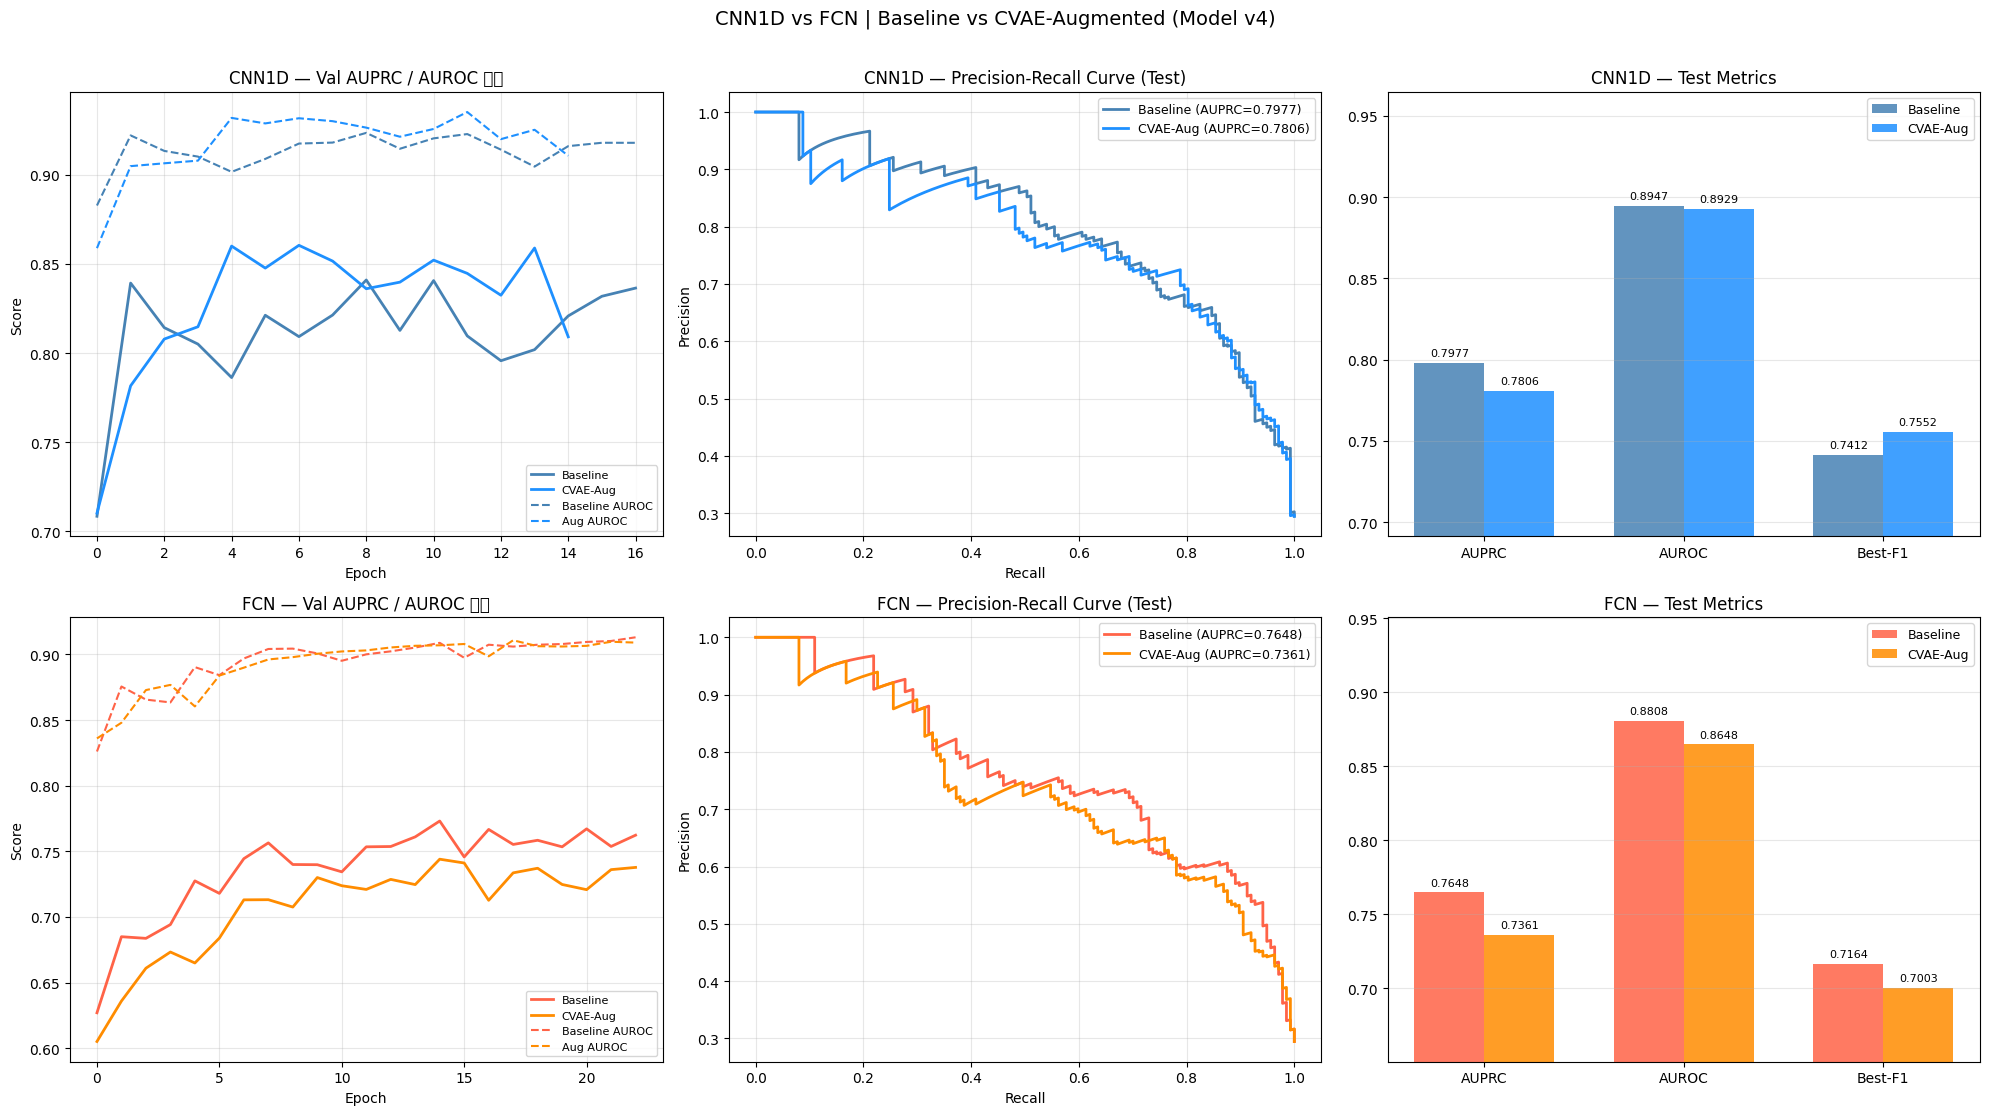

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(20, 11))

results = {
    'CNN1D\nBaseline': res_cnn_base,
    'CNN1D\nCVAE-Aug': res_cnn_aug,
    'FCN\nBaseline':   res_fcn_base,
    'FCN\nCVAE-Aug':   res_fcn_aug,
}
colors = {'CNN1D\nBaseline':'steelblue', 'CNN1D\nCVAE-Aug':'dodgerblue',
          'FCN\nBaseline':'tomato',      'FCN\nCVAE-Aug':'darkorange'}

# ── Row 0: CNN1D ─────────────────────────────────────────────────────────────
for row, (clf_name, res_b, res_a, hist_b, hist_a) in enumerate([
    ('CNN1D', res_cnn_base, res_cnn_aug, hist_cnn_base, hist_cnn_aug),
    ('FCN',   res_fcn_base, res_fcn_aug, hist_fcn_base, hist_fcn_aug),
]):
    # (1) Val AUPRC 곡선
    ax = axes[row][0]
    ax.plot(hist_b['val_auprc'], label='Baseline',  color='steelblue' if row==0 else 'tomato',    lw=2)
    ax.plot(hist_a['val_auprc'], label='CVAE-Aug',  color='dodgerblue' if row==0 else 'darkorange', lw=2)
    ax.plot(hist_b['val_auroc'], label='Baseline AUROC',  color='steelblue' if row==0 else 'tomato',    lw=1.5, ls='--')
    ax.plot(hist_a['val_auroc'], label='Aug AUROC',        color='dodgerblue' if row==0 else 'darkorange', lw=1.5, ls='--')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Score')
    ax.set_title(f'{clf_name} — Val AUPRC / AUROC 곡선')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # (2) PR Curve
    ax = axes[row][1]
    for res, label, c in [(res_b,'Baseline','steelblue' if row==0 else 'tomato'),
                           (res_a,'CVAE-Aug','dodgerblue' if row==0 else 'darkorange')]:
        prec, rec, _ = precision_recall_curve(res['trues'], res['probs'])
        ax.plot(rec, prec, label=f"{label} (AUPRC={res['auprc']:.4f})", color=c, lw=2)
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(f'{clf_name} — Precision-Recall Curve (Test)')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    # (3) 지표 막대
    ax = axes[row][2]
    metrics  = ['AUPRC', 'AUROC', 'Best-F1']
    base_val = [res_b['auprc'], res_b['auroc'], res_b['best_f1']]
    aug_val  = [res_a['auprc'], res_a['auroc'], res_a['best_f1']]
    x = np.arange(len(metrics)); w = 0.35
    c1 = 'steelblue' if row==0 else 'tomato'
    c2 = 'dodgerblue' if row==0 else 'darkorange'
    bars1 = ax.bar(x - w/2, base_val, w, label='Baseline', color=c1, alpha=0.85)
    bars2 = ax.bar(x + w/2, aug_val,  w, label='CVAE-Aug', color=c2, alpha=0.85)
    for bars in [bars1, bars2]:
        for bar in bars:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                    f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
    all_v = base_val + aug_val
    ax.set_xticks(x); ax.set_xticklabels(metrics)
    ax.set_ylim(max(0, min(all_v)-0.05), min(1.0, max(all_v)+0.07))
    ax.set_title(f'{clf_name} — Test Metrics')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('CNN1D vs FCN | Baseline vs CVAE-Augmented (Model v4)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/clf_comparison_fcn.png', dpi=150, bbox_inches='tight')
plt.show()


## 22. 최종 요약 출력

In [ ]:
print('\n' + '='*65)
print(f'  Model v4 CVAE Augmentation 효과 — Classifier 비교')
print('='*65)
print(f'  {"":20s}  {"AUPRC":>8}  {"AUROC":>8}  {"Best-F1":>8}')
print('-'*65)

for label, res in [('CNN1D Baseline', res_cnn_base), ('CNN1D CVAE-Aug', res_cnn_aug),
                   ('FCN   Baseline', res_fcn_base), ('FCN   CVAE-Aug', res_fcn_aug)]:
    print(f'  {label:20s}  {res["auprc"]:8.4f}  {res["auroc"]:8.4f}  {res["best_f1"]:8.4f}')

print('-'*65)
d_cnn = res_cnn_aug['auprc'] - res_cnn_base['auprc']
d_fcn = res_fcn_aug['auprc'] - res_fcn_base['auprc']
d_cnn_roc = res_cnn_aug['auroc'] - res_cnn_base['auroc']
d_fcn_roc = res_fcn_aug['auroc'] - res_fcn_base['auroc']
print(f'  {"Δ CNN1D":20s}  {d_cnn:+8.4f}  {d_cnn_roc:+8.4f}')
print(f'  {"Δ FCN":20s}  {d_fcn:+8.4f}  {d_fcn_roc:+8.4f}')
print('='*65)

torch.save({
    'res_cnn_base': res_cnn_base, 'res_cnn_aug': res_cnn_aug,
    'res_fcn_base': res_fcn_base, 'res_fcn_aug': res_fcn_aug,
    'delta_cnn_auprc': d_cnn,     'delta_fcn_auprc': d_fcn,
}, f'{OUT_DIR}/clf_results_v4_fcn.pt')
print(f'저장 완료: {OUT_DIR}/clf_results_v4_fcn.pt')



  Model v4 CVAE Augmentation 효과 — Classifier 비교
                           AUPRC     AUROC   Best-F1
-----------------------------------------------------------------
  CNN1D Baseline          0.7977    0.8947    0.7412
  CNN1D CVAE-Aug          0.7806    0.8929    0.7552
  FCN   Baseline          0.7648    0.8808    0.7164
  FCN   CVAE-Aug          0.7361    0.8648    0.7003
-----------------------------------------------------------------
  Δ CNN1D                -0.0171   -0.0018
  Δ FCN                  -0.0287   -0.0160
저장 완료: /content/drive/MyDrive/vtac_project/outputs/cvae_v4/clf_results_v4_fcn.pt
